# 01 · Halo catalog and theory inputs

Turns the Abacus `c0000_ph000` lightcone into the inputs every later stage depends on:
the lens `n(z)`, and the halo mass function and bias evaluated at that exact cosmology.

`validate_three_probe_catalog_preflight.py` · `validate_three_probe_catalog_theory.py`

In [1]:
import json, pathlib, sys
import numpy as np, h5py
import matplotlib.pyplot as plt
ROOT = pathlib.Path("/mnt/ceph/users/spandey/ltu-godmax/GODMAX")
sys.path.insert(0, str(ROOT / "notebooks/SBI_validate/common"))
DATA = ROOT / "data/SBI_validate"
VAL  = DATA / "three_probe_mock/validation"
INF  = DATA / "three_probe_inference"
MSBI = DATA / "mock_sbi"
BLUE, ORANGE, GREEN, INK2, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#52514e", "#dedcd6"
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "axes.edgecolor": GRID, "xtick.color": INK2, "ytick.color": INK2,
                     "font.size": 10.5, "axes.spines.top": False, "axes.spines.right": False})
SPECTRA = ["gy", "gkappa", "gtau"]
LBL = {"gg": r"$g \times g$", "gy": r"$g \times y$",
       "gkappa": r"$g \times \kappa_{\rm CMB}$", "gtau": r"$g \times \tau$"}

In [2]:
d = np.load(VAL / "catalog_theory_validation_arrays.npz", allow_pickle=True)
summary = json.loads((VAL / "catalog_theory_validation.json").read_text())
prov = json.loads(str(d["provenance_json"]))
print("git commit:", prov["git_commit"][:12],
      " worktree dirty:", prov["git_worktree_dirty"])
print("inputs:", list(prov["inputs"])[:4])
print("arrays:", len(d.files))

git commit: 29c3a2776ace  worktree dirty: True
inputs: ['contract_module', 'default_params', 'experiment_config', 'validation_script']
arrays: 28


### Lens n(z) from the catalog

66,159,463 haloes over z = 0.300 - 0.500


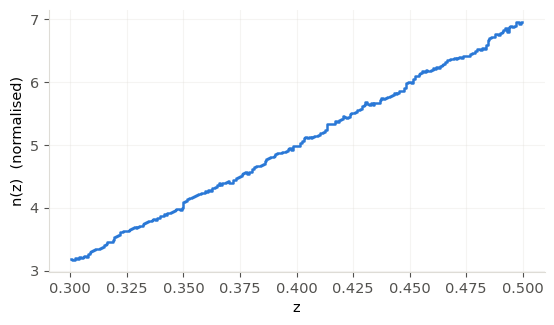

In [3]:
e = np.asarray(d["robust_z_edges"], float); c = np.asarray(d["primary_robust_nz_counts"], float)
ctr = 0.5 * (e[:-1] + e[1:])
fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.step(ctr, c / np.trapz(c, ctr), where="mid", color=BLUE, lw=1.8)
ax.set_xlabel("z"); ax.set_ylabel("n(z)  (normalised)"); ax.grid(alpha=.3, color=GRID)
print(f"{c.sum():,.0f} haloes over z = {e[0]:.3f} - {e[-1]:.3f}")

### Catalog HMF against Tinker-2010, and the halo bias\n\nRatio near 1 means the catalog reproduces the theory HMF it will be compared against.

number-weighted bias at the catalog z-range: [0.972 0.989 1.008 1.027]


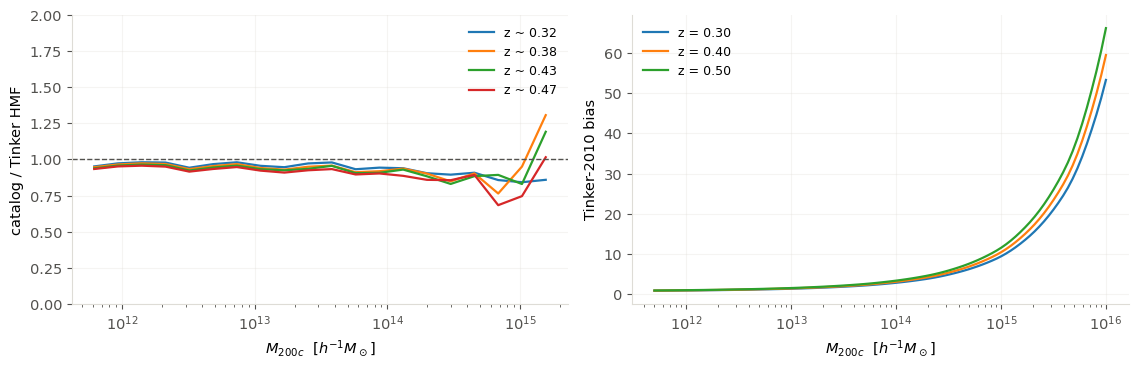

In [4]:
r = np.asarray(d["primary_catalog_over_theory_hmf"], float)
me = np.asarray(d["mass_edges_hmsun"], float); mc = np.sqrt(me[:-1] * me[1:])
zc = np.asarray(d["diagnostic_z_edges"], float)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
for i in range(r.shape[0]):
    axes[0].plot(mc, r[i], lw=1.6, label=f"z ~ {0.5*(zc[i]+zc[i+1]):.2f}")
axes[0].axhline(1.0, color=INK2, lw=1.0, ls="--")
axes[0].set_xscale("log"); axes[0].set_ylim(0, 2)
axes[0].set_xlabel(r"$M_{200c}$  [$h^{-1}M_\odot$]"); axes[0].set_ylabel("catalog / Tinker HMF")
axes[0].legend(frameon=False, fontsize=9); axes[0].grid(alpha=.3, color=GRID)
bz = np.asarray(d["baseline_z"], float); bb = np.asarray(d["baseline_bias"], float)
bm = np.asarray(d["baseline_mass_hmsun"], float)
for j in (0, len(bz)//2, len(bz)-1):
    axes[1].plot(bm, bb[j], lw=1.6, label=f"z = {bz[j]:.2f}")
axes[1].set_xscale("log"); axes[1].set_xlabel(r"$M_{200c}$  [$h^{-1}M_\odot$]")
axes[1].set_ylabel("Tinker-2010 bias"); axes[1].legend(frameon=False, fontsize=9)
axes[1].grid(alpha=.3, color=GRID)
fig.tight_layout()
print("number-weighted bias at the catalog z-range:",
      np.round(np.asarray(d["conditioned_bias_primary"], float), 3))